Tutorial from [link](https://pertpy.readthedocs.io/en/latest/tutorials/notebooks/sccoda.html)

Install Jax for 
```bash
pyenv virtualenv 3.11.8 scoda-gpu
pyenv activate scoda-gpu
pip install --upgrade "jax[cuda12_local]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
pip uninstall -y jax jaxlib jax-cuda12-plugin
pip install jax==0.4.31 jaxlib==0.4.31+cuda12.cudnn89 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
pip install scvi-tools pertpy scanpy pandas matplotlib seaborn
pip install jupyter ipykernel
python -m ipykernel install --user --name=scoda-gpu --display-name="scCODA GPU"
```


Resutls depends on:
- reference cell type
    - choose vy me
    - autamtically picked
- level of granularity in cell type annotation
- Covariates in formula

In [13]:
# import os
# os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.2/targets/x86_64-linux/lib:' + os.environ.get('LD_LIBRARY_PATH', '')
# os.environ['CUDA_HOME'] = '/usr/local/cuda-12.2'
# import jax
# print('Backend:', jax.default_backend())
# print('Devices:', jax.devices())

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import json

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

ADATA = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
TISSUE = "Striatum"
SAVE_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/scCODA"
NUTS_ITERATIONS=5000

MAPPING_CELL_TYPE_JSON = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"
# Covariates to use for stat test
COV_TO_BRING_TO_AGGREGATED_VERSION = [CONTRAST_VARIABLE, "sex", SAMPLE_VARIABLE]


FORMULA = f"C({CONTRAST_VARIABLE}, Treatment('{CONTRAST_BASELINE}')) + sex"
FORMULA

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


"C(condition, Treatment('Control')) + sex"

In [4]:
!export LD_LIBRARY_PATH=/usr/local/cuda-12.2/targets/x86_64-linux/lib:$LD_LIBRARY_PATH
!export CUDA_HOME=/usr/local/cuda-12.2
# export XLA_PYTHON_CLIENT_PREALLOCATE=false
# export XLA_PYTHON_CLIENT_MEM_FRACTION=0.5

In [5]:
os.environ['JAX_PLATFORMS'] = 'cuda'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # Don't preallocate all GPU memory
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'  # Use up to 90% of GPU memory

import jax
import jax.numpy as jnp
import pertpy as pt

print("Backend:", jax.default_backend())  # Must be 'gpu'
print("Devices:", jax.devices())

# Simple GPU test
x = jnp.ones((10, 10))
result = jnp.sum(x @ x.T)
print("GPU compute works:", result)

Backend: gpu
Devices: [CudaDevice(id=0)]
GPU compute works: 1000.0


# Define specific annotations for cell level

In [14]:
adata = sc.read_h5ad(ADATA)# backed="r")
adata.obs["tissue"] = TISSUE

In [7]:
adata#.obs.Neighborhood_name.unique()

AnnData object with n_obs × n_vars = 231080 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes

# Analyse

In [8]:
def run_scCODA(adata, CT_COL, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, print_summary=False, NUTS_ITERATIONS=5000, automatic_reference_absence_threshold=0.1):

    # initialise
    sccoda = pt.tl.Sccoda()

    # Create sample level counts (sort of pseudobulikng)
        # Y matrix --> (N×K) - cell counts per sample
    mdata = sccoda.load(
        adata,
        type="cell_level", #cell_level --> each row of adat is a cell
        generate_sample_level=True,
        cell_type_identifier=CT_COL, # cell type col
        sample_identifier=SAMPLE_VARIABLE, #Each unique value = one biological replicate
        covariate_obs=COV_TO_BRING_TO_AGGREGATED_VERSION, #  "Which metadata do I want to preserve?" (only if all cells have same value it is taken)
        #levels_orig=[CONTRAST_BASELINE, CONTRAST_STIM],
        modality_key_1="coda"
    )
    print(mdata)

    #     # 🔍 DIAGNOSTIC: Check for missing values
    # print(f"\nSample-level data shape: {mdata['coda'].shape}")
    # print(f"\nMissing values in covariates:")
    # for cov in COV_TO_BRING_TO_AGGREGATED_VERSION:
    #     n_missing = mdata['coda'].obs[cov].isna().sum()
    #     if n_missing > 0:
    #         print(f"  {cov}: {n_missing} missing")
    #         print(f"    Samples with missing {cov}:")
    #         print(f"    {mdata['coda'].obs[mdata['coda'].obs[cov].isna()].index.tolist()}")
    

    ###########################################################

    proportions_plot = sccoda.plot_boxplots(mdata, feature_name=CONTRAST_VARIABLE, add_dots=False, figsize=(20,5), return_fig=True)
    #plt.show()

    ###########################################################

    # Set up statical mdole
    # Creates the X matrix (N×M)
    # Selects reference cell type (sets β_ref = 0)
    mdata = sccoda.prepare(
        mdata,
        formula=FORMULA, 
        reference_cell_type=REFERENCE_CT,
        automatic_reference_absence_threshold=automatic_reference_absence_threshold, 
            #Maximum fraction of samples where cell type can be absent
            # Why: Prevents rare cell types from being selected as reference
    )
    # Check which reference was selected:
    print(f"Selected reference: {mdata['coda'].uns['scCODA_params']['reference_cell_type']}")

    ###########################################################

    # Run HMC Sampling ..>  #  (NUTS = No-U-Turn Sampler, an improved HMC)
    sccoda.run_nuts(
        mdata,
        num_warmup=500, 
        num_samples=NUTS_ITERATIONS, # posterior samples to keep
            # final soluton (betas) are mean of each sample. i cna estimate the variance. and porb=hwp poften b!=0
        rng_key=42, # seed
    )

    ###########################################################

    if print_summary:
        summary = sccoda.summary(mdata,extended=True)
        print(summary)

    ###########################################################

    results = pd.DataFrame(sccoda.credible_effects( ########## ATTENTION: credible_effects FIRST — this sets the FDR threshold in mdata in-place
        # P_inclusion(cell_type, constion) = number beta_constion > 0.001 / tot betas
        # which is a good thr for P_inclussion?
        # take thr that make the FDR selected
        mdata,
        est_fdr=0.05, # FDR step finds the optimal threshold of P_inclusion automatically
    )).rename(columns={"Final Parameter": "is_significant"})
    results = results.reset_index()
    results['Covariate'] = results["Covariate"].str.extract(r'\[T\.(.*?)\]')[0]
    #display(results)

    #intercept_df = sccoda.get_intercept_df(mdata)
    effect_df = sccoda.get_effect_df(mdata)
    effect_df = effect_df.reset_index()
    effect_df['Covariate'] = effect_df["Covariate"].str.extract(r'T\.(.*)$')[0]
    #display(effect_df)

    merged_df = effect_df.merge(
        results, 
        how='left',        
        validate="one_to_one"
    )

    display(merged_df[(merged_df["Covariate"] == CONTRAST_STIM) & (merged_df["is_significant"])])

    ###########################################################

    # If there are no signficant effects --> impossibel to plot the barplot
    effects_df = sccoda.get_effect_df(mdata)
    nonzero = effects_df.query("`log2-fold change` != 0").reset_index() 
    display(nonzero)
    contrast_nonzero = nonzero[nonzero["Covariate"].str.contains(CONTRAST_VARIABLE, na=False)]

    if contrast_nonzero.shape[0] > 0:
        barplot = sccoda.plot_effects_barplot(
            mdata,
            covariates=[CONTRAST_VARIABLE],
            figsize=(5, 20),
            parameter="log2-fold change",
            return_fig=True,
        )
        barplot.savefig(f"{save_folder}/logFC_plot.png", bbox_inches='tight', dpi=300)
    else:
        print("All effects shrunk to zero — no barplot generated.")

    ###########################################################

    merged_df.to_csv(f"{save_folder}/results.csv", index=False)
    proportions_plot.savefig(f"{save_folder}/proportions.png", bbox_inches='tight', dpi=300)  # Changed to .png

    return sccoda, mdata, merged_df

In [10]:
def run_scCODA_for_NucSeq_dataset(adata, subfolder_save, LEVELS_ANNOTATION, CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, SAMPLE_VARIABLE, SAVE_FOLDER, FORMULA, REFERENCE_CT, NUTS_ITERATIONS, tissue_col="tissue", ):

    df_list = []
    for tissue in adata.obs[tissue_col].unique().tolist():
        for level_annotation in LEVELS_ANNOTATION:

            print(tissue, level_annotation)

            # Samples that miss some vital info
            bad_samples = [i for cov in [CONTRAST_VARIABLE, *COV_TO_BRING_TO_AGGREGATED_VERSION] for i in adata.obs[adata.obs[cov].isna()][SAMPLE_VARIABLE].unique().tolist()]

            # Filter
            adata_sub = adata[
                    (adata.obs[tissue_col] == tissue) & 
                    (~ adata.obs[SAMPLE_VARIABLE].isin(bad_samples))
                ].to_memory().copy()
            print(adata_sub.obs[level_annotation].value_counts())
            
            # Save folder
            save_folder = f"{SAVE_FOLDER}/{subfolder_save}/{tissue}/{level_annotation}"
            os.makedirs(save_folder, exist_ok=True)

            sccoda, mdata, merged_df = run_scCODA(adata_sub, level_annotation, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, NUTS_ITERATIONS=NUTS_ITERATIONS)

            merged_df["tissue"] = tissue
            merged_df["annotation"] = level_annotation

            df_list.append(merged_df)        

        #     break
        # break

    df = pd.concat(df_list)
    df.to_csv(f"{SAVE_FOLDER}/{subfolder_save}/merged_df.csv", index=False)

    return df

# With All cells

In [15]:
REFERENCE_CT_ALL_CELLS = "eMSN_D1D2" #"automatic"
LEVELS_ANNOTATION_ALL_CELLS = ["ct_for_deg"] #["Class_name", "Subclass_name", "Group_name", "spn_type", "spn_receptor_type"]

In [16]:
with open(MAPPING_CELL_TYPE_JSON, 'r') as f:
    classifications = json.load(f)

for cat in LEVELS_ANNOTATION_ALL_CELLS:
    if cat in adata.obs.columns:
        continue
    # fillna with ORIGINAL VALUES
    adata.obs[cat] = adata.obs["Group_name"].map(classifications[cat]).fillna(adata.obs["Group_name"])

Striatum ct_for_deg
ct_for_deg
Oligodendrocyte      122865
Astrocyte             27714
-Low_quality          14435
Matrix_D2             11745
Matrix_D1             11037
Microglia              9868
non-MSN                8335
OPC                    7219
Patch_D1               4098
Patch_D2               3171
eMSN_D1D2              2830
Ependymal              1451
eMSN_NUDAP             1359
-TAFA1                 1005
eMSN_StrioMat           885
Macrophages             761
Endothelial_BBB         711
COP                     440
Lymphocyte              415
Pericytes               334
Fibroblasts             230
SmoothMuscleCells        88
Monocytes                81
Name: count, dtype: int64
MuData object with n_obs × n_vars = 47 × 23
  var:	'n_cells'
  1 modality
    coda:	47 x 23
      obs:	'donor_id', 'condition', 'sex'
      var:	'n_cells'
Selected reference: eMSN_D1D2


sample: 100%|██████████| 5500/5500 [19:42<00:00,  4.65it/s, 511 steps of size 1.06e-02. acc. prob=0.80] 
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
0,XDP,-Low_quality,-0.819316,-1.100,-0.539,0.144,1.0000,244.685380,-0.895176,True
2,XDP,Astrocyte,0.512303,0.208,0.780,0.140,0.9994,741.438741,1.025945,True
9,XDP,Matrix_D1,-1.493475,-1.790,-1.200,0.156,1.0000,119.679172,-1.867781,True
10,XDP,Matrix_D2,-1.457300,-1.762,-1.153,0.160,1.0000,127.483825,-1.815592,True
13,XDP,OPC,-0.341393,-0.611,0.002,0.206,0.7360,151.546992,-0.205679,True
15,XDP,Patch_D1,-0.785661,-1.124,-0.416,0.183,1.0000,77.217649,-0.846622,True
16,XDP,Patch_D2,-0.869654,-1.246,-0.465,0.201,1.0000,58.652771,-0.967799,True


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
0,"C(condition, Treatment('Control'))T.XDP",-Low_quality,-0.819316,-1.100,-0.539,0.144,1.0000,244.685380,-0.895176
1,"C(condition, Treatment('Control'))T.XDP",-TAFA1,0.000000,-0.503,0.330,0.134,0.3142,30.002753,0.286847
2,"C(condition, Treatment('Control'))T.XDP",Astrocyte,0.512303,0.208,0.780,0.140,0.9994,741.438741,1.025945
3,"C(condition, Treatment('Control'))T.XDP",COP,0.000000,-0.515,0.363,0.131,0.3246,23.087449,0.286847
4,"C(condition, Treatment('Control'))T.XDP",Endothelial_BBB,0.000000,-0.371,0.480,0.134,0.3192,28.970821,0.286847
5,"C(condition, Treatment('Control'))T.XDP",Ependymal,0.000000,-0.088,0.823,0.261,0.5442,33.058845,0.286847
6,"C(condition, Treatment('Control'))T.XDP",Fibroblasts,0.000000,-0.209,0.781,0.206,0.3938,15.093877,0.286847
7,"C(condition, Treatment('Control'))T.XDP",Lymphocyte,0.000000,-0.341,0.659,0.165,0.3584,17.554128,0.286847
8,"C(condition, Treatment('Control'))T.XDP",Macrophages,0.000000,-0.122,0.748,0.228,0.4718,28.454011,0.286847
9,"C(condition, Treatment('Control'))T.XDP",Matrix_D1,-1.493475,-1.790,-1.200,0.156,1.0000,119.679172,-1.867781


/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


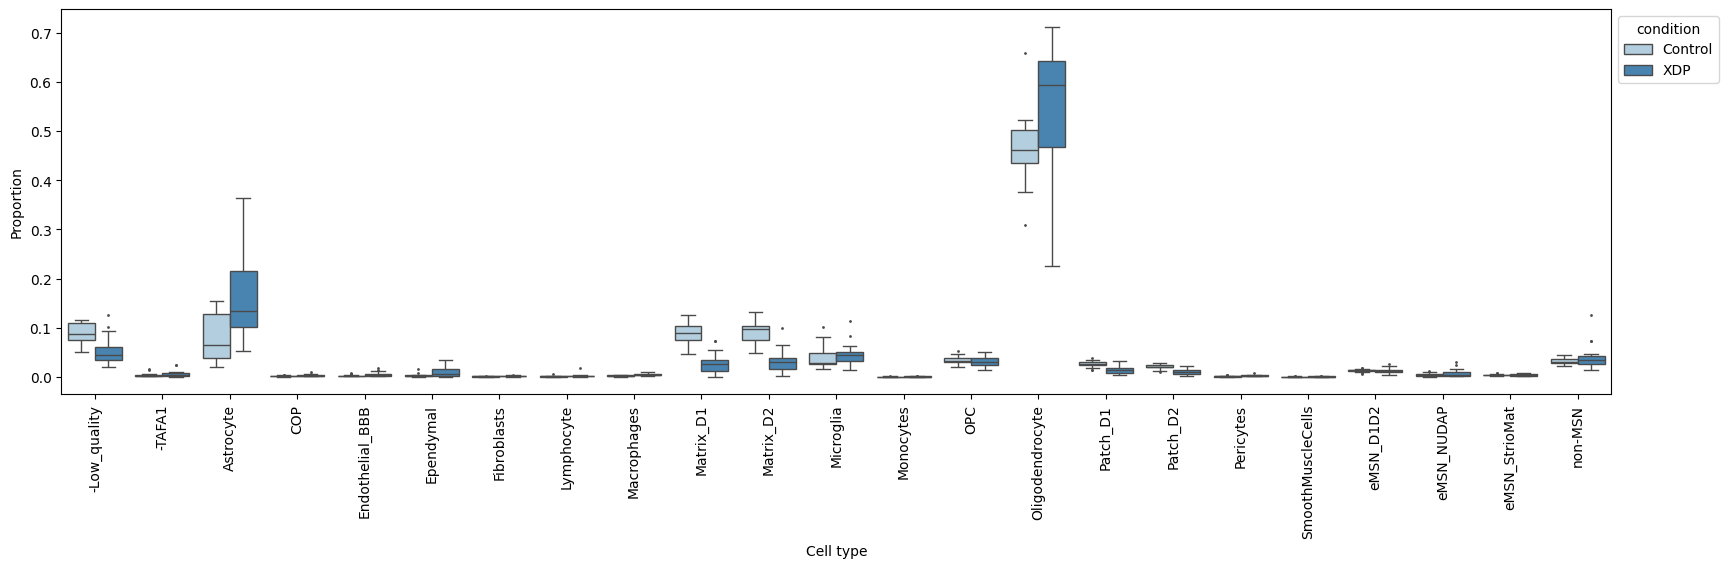

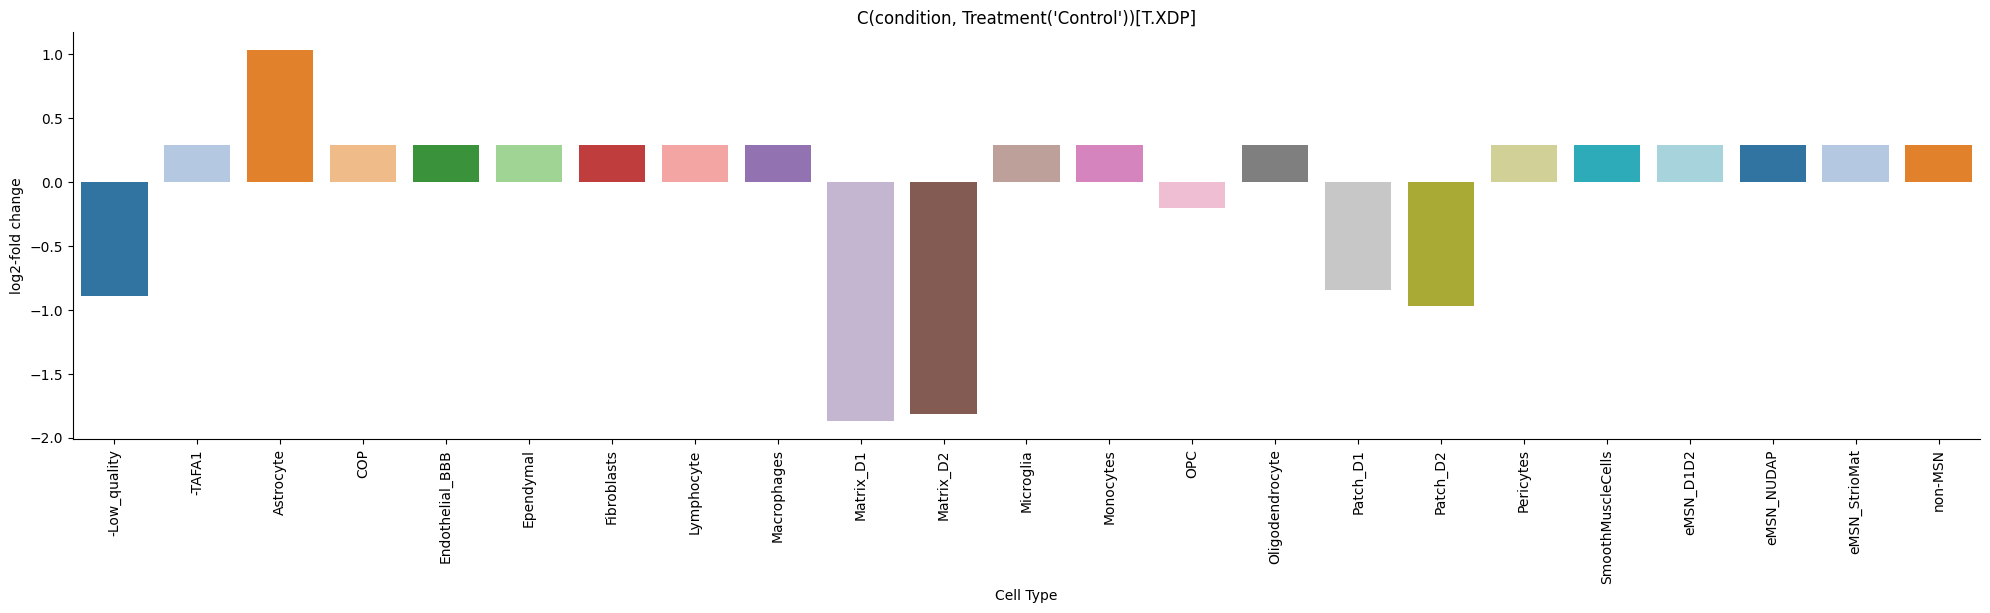

In [17]:
df_all_cells = run_scCODA_for_NucSeq_dataset(
    adata, 
    subfolder_save="all_cells", 
    LEVELS_ANNOTATION=LEVELS_ANNOTATION_ALL_CELLS, 
    CONTRAST_VARIABLE=CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION=COV_TO_BRING_TO_AGGREGATED_VERSION, 
    SAMPLE_VARIABLE=SAMPLE_VARIABLE, SAVE_FOLDER=SAVE_FOLDER, FORMULA=FORMULA, 
    REFERENCE_CT=REFERENCE_CT_ALL_CELLS, NUTS_ITERATIONS=NUTS_ITERATIONS,
    tissue_col="tissue",
)


In [ ]:

# df_list = []
# for tissue in adata.obs.tissue.unique().tolist():
#     for level_annotation in LEVELS_ANNOTATION:

#         print(tissue, level_annotation)

#         # Samples that miss some vital info
#         bad_samples = [i for cov in [CONTRAST_VARIABLE, *COV_TO_BRING_TO_AGGREGATED_VERSION] for i in adata.obs[adata.obs[cov].isna()][SAMPLE_VARIABLE].unique().tolist()]

#         # Filter
#         adata_sub = adata[
#                 (adata.obs.tissue == tissue) & 
#                 (~ adata.obs[SAMPLE_VARIABLE].isin(bad_samples))
#             ].to_memory().copy()
        
#         # Save folder
#         save_folder = f"{SAVE_FOLDER}/all_cells/{tissue}/{level_annotation}"
#         os.makedirs(save_folder, exist_ok=True)

#         sccoda, mdata, merged_df = run_scCODA(adata_sub, level_annotation, SAMPLE_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION, CONTRAST_VARIABLE, FORMULA, REFERENCE_CT, save_folder, NUTS_ITERATIONS=NUTS_ITERATIONS)

#         merged_df["tissue"] = tissue
#         merged_df["annotation"] = level_annotation

#         df_list.append(merged_df)        

#     #     break
#     # break

# df = pd.concat(df_list)
# df.to_csv(f"{SAVE_FOLDER}/all_cells/merged_df.csv", index=False)

# With subset of cells

- only neruons
- split in Non-MSN and all the others ne by one

In [ ]:
# Select only neruons
adata_n = adata[adata.obs["Neighborhood_name"] != "Nonneuron"].to_memory().copy()

# SET refecne cell type as non-msn
REFERENCE_CT_ONLY_NEURONS = "NON_MSN"
LEVELS_ANNOTATION_ONLY_NEURONS = ["Original_group_name", "spn_type", "spn_receptor_type"]

In [ ]:
with open(MAPPING_CELL_TYPE_JSON, 'r') as f:
    classifications = json.load(f)

for cat in LEVELS_ANNOTATION_ONLY_NEURONS:
    print(cat)
    if cat in adata_n.obs.columns:
        continue
    # fillna with "NON_MSN"
    adata_n.obs[cat] = adata_n.obs["Group_name"].map(classifications[cat]).fillna(REFERENCE_CT_ONLY_NEURONS)

adata_n.obs[cat].value_counts()


Original_group_name
spn_type
spn_receptor_type


spn_receptor_type
NON_MSN    79678
D1         53447
D2         29410
D1D2        2858
Name: count, dtype: int64

In [ ]:
df_only_neurons = run_scCODA_for_NucSeq_dataset(
    adata_n, 
    subfolder_save="only_neurons", 
    LEVELS_ANNOTATION=LEVELS_ANNOTATION_ONLY_NEURONS, 
    CONTRAST_VARIABLE=CONTRAST_VARIABLE, COV_TO_BRING_TO_AGGREGATED_VERSION=COV_TO_BRING_TO_AGGREGATED_VERSION, 
    SAMPLE_VARIABLE=SAMPLE_VARIABLE, SAVE_FOLDER=SAVE_FOLDER, FORMULA=FORMULA, 
    REFERENCE_CT=REFERENCE_CT_ONLY_NEURONS, NUTS_ITERATIONS=NUTS_ITERATIONS,
    tissue_col="tissue",
)


# Merge resutls in single df

In [12]:
import glob

df_list = []
for category_name in ["all_cells", "only_neurons"]:
    csv_files = glob.glob(f"{SAVE_FOLDER}/{category_name}/*/*/results.csv")  # adjust filename pattern if needed
    
    for f in csv_files:
        parts = f.split("/")
        tissue, level_annotation = parts[-3], parts[-2]
        df = pd.read_csv(f)
        df["cell_used"] = category_name
        df["tissue"] = tissue
        df["annotation"] = level_annotation
        df_list.append(df)

    df = pd.concat(df_list)
    print(f"{category_name}: merged {len(csv_files)} files → {df.shape}")

    #break

df.to_csv(f"{SAVE_FOLDER}/merged_df.csv", index=False)
df

all_cells: merged 15 files → (1278, 13)
only_neurons: merged 9 files → (1392, 13)


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant,cell_used,tissue,annotation
0,XDP,AMY-SLEA-BNST D1 GABA,0.000000,-0.010,0.633,0.207,0.7220,67.847761,0.310202,False,all_cells,Striatum,spn_receptor_type
1,XDP,AMY-SLEA-BNST GABA,0.000000,-0.292,0.501,0.148,0.4148,21.612382,0.310202,False,all_cells,Striatum,spn_receptor_type
2,XDP,Astrocyte,0.580393,0.388,0.762,0.097,1.0000,757.981812,1.147532,True,all_cells,Striatum,spn_receptor_type
3,XDP,B cells,0.000000,-0.217,0.440,0.133,0.4084,72.549304,0.310202,False,all_cells,Striatum,spn_receptor_type
4,XDP,BAM,0.000000,-0.164,0.672,0.206,0.5220,17.765642,0.310202,False,all_cells,Striatum,spn_receptor_type
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,M,STRd D2 StrioMat Hybrid MSN,0.000000,-0.817,0.368,0.234,0.5066,1.490181,0.000000,False,only_neurons,SN,Original_group_name
16,M,STRd D2 Striosome MSN,0.000000,-0.902,0.392,0.259,0.5090,1.017041,0.000000,False,only_neurons,SN,Original_group_name
17,M,STRv D1 MSN,0.000000,-0.861,0.314,0.255,0.5258,2.524133,0.000000,False,only_neurons,SN,Original_group_name
18,M,STRv D1 NUDAP MSN,0.000000,-0.424,0.385,0.137,0.4316,5.429774,0.000000,False,only_neurons,SN,Original_group_name


# Plot summary by cell type

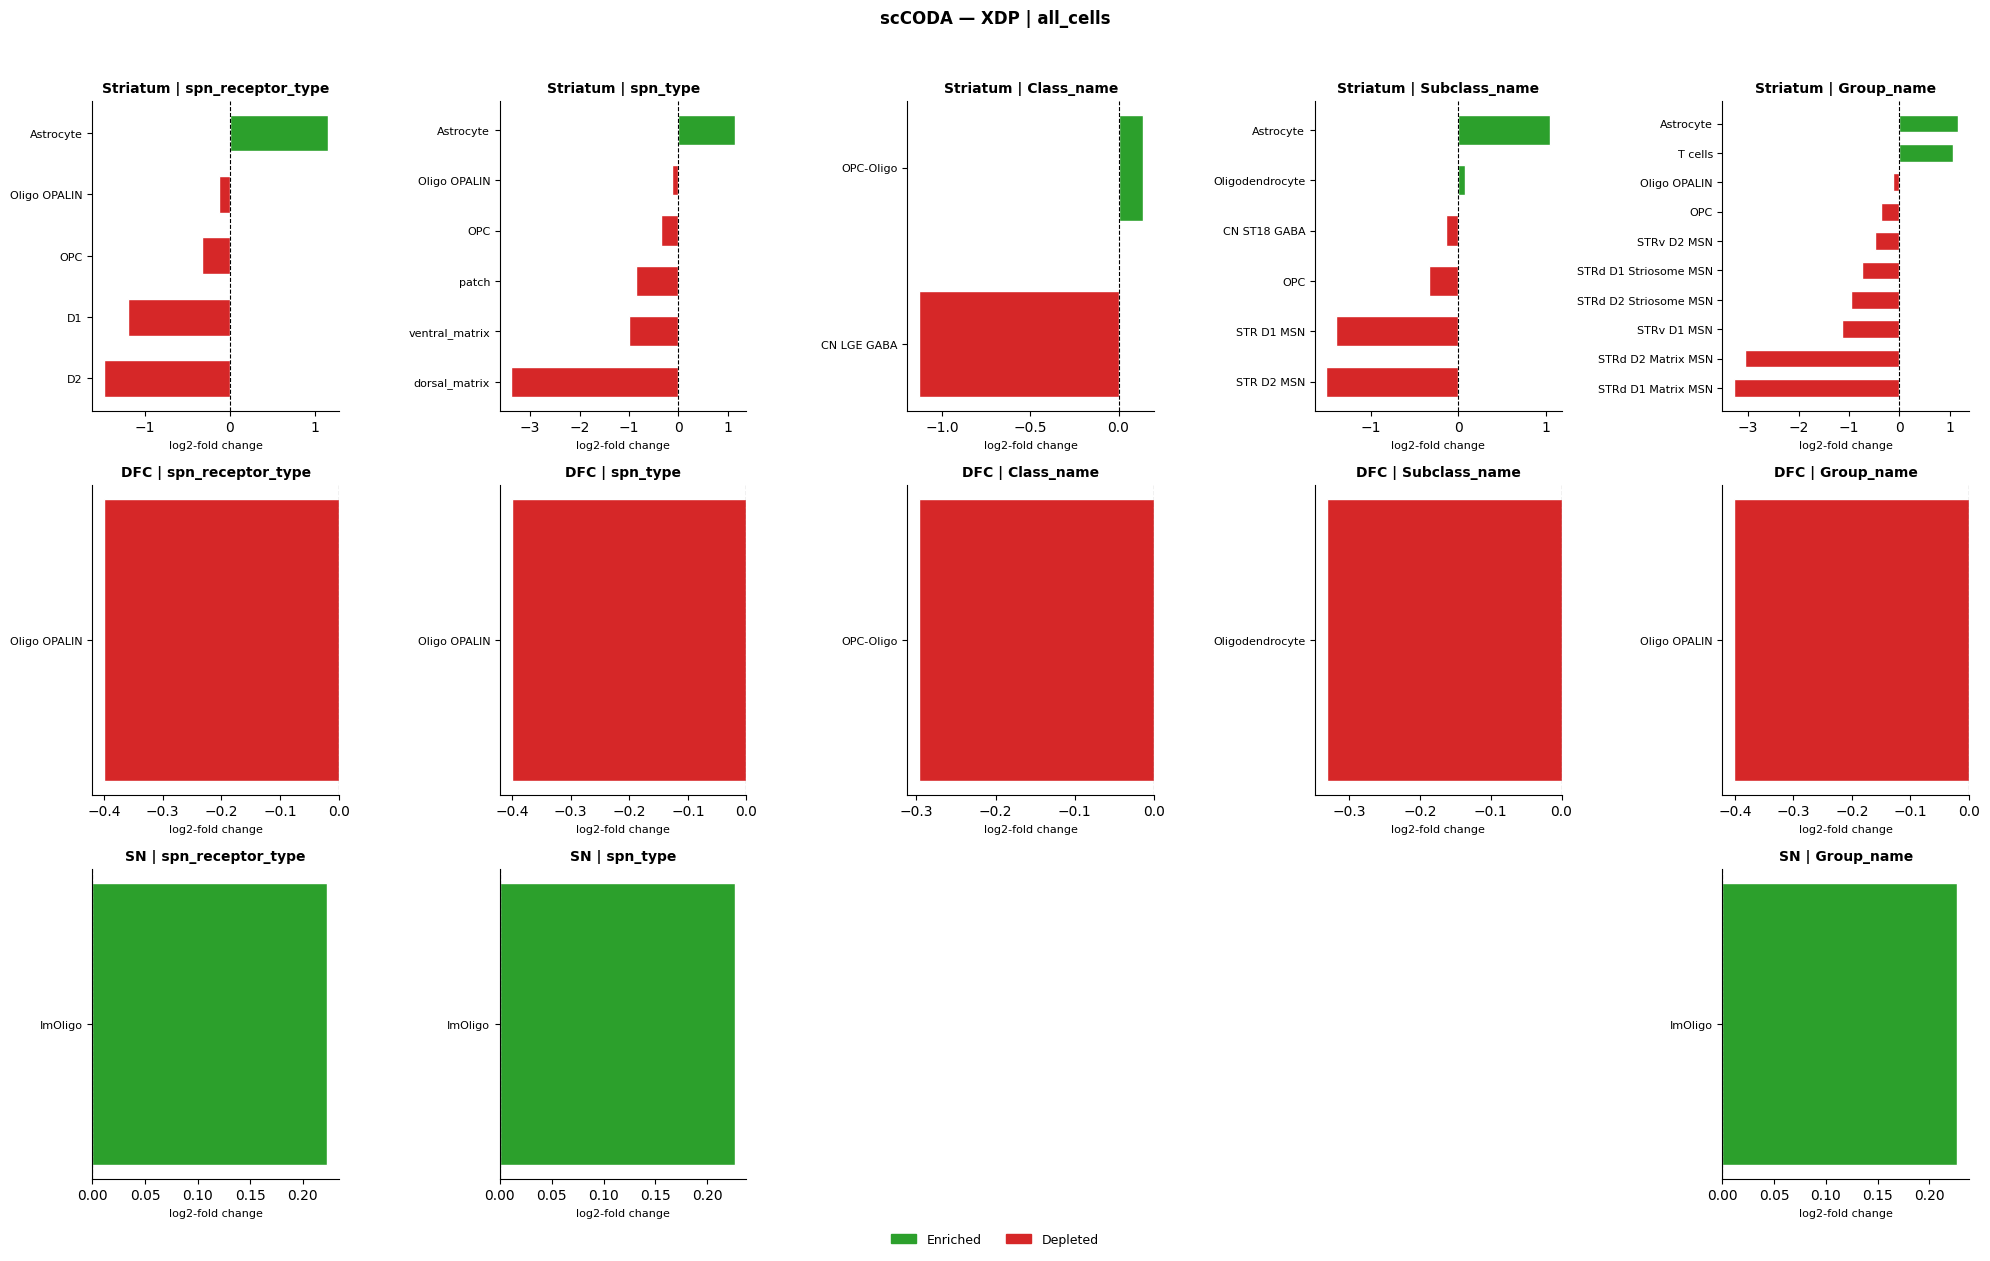

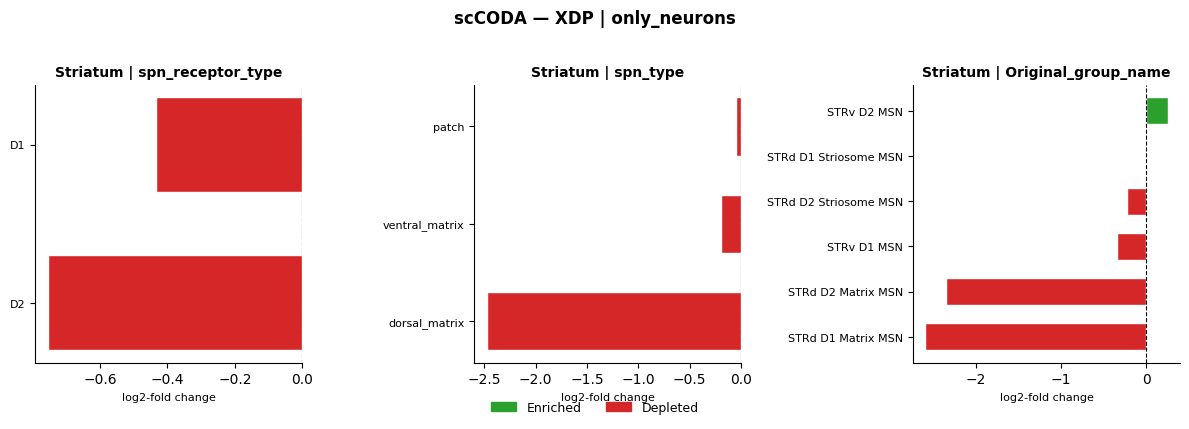

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_significant_cell_types(df):
    sig = df[(df["is_significant"]) & (df["Covariate"] == "XDP")].copy()
    if sig.empty:
        print("No significant cell types found for XDP.")
        return

    for cell_used, df_cell in sig.groupby("cell_used"):
        tissues = df_cell["tissue"].unique()
        annotations = df_cell["annotation"].unique()
        n_rows, n_cols = len(tissues), len(annotations)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)

        for r, tissue in enumerate(tissues):
            for c, annotation in enumerate(annotations):
                ax = axes[r][c]
                group = df_cell[(df_cell["tissue"] == tissue) & (df_cell["annotation"] == annotation)]

                if group.empty:
                    ax.set_visible(False)
                    continue

                group = group.sort_values("log2-fold change")
                colors = ["#d62728" if v < 0 else "#2ca02c" for v in group["log2-fold change"]]
                ax.barh(group["Cell Type"], group["log2-fold change"], color=colors, edgecolor="white", height=0.6)
                ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
                ax.set_title(f"{tissue} | {annotation}", fontsize=10, fontweight="bold")
                ax.set_xlabel("log2-fold change", fontsize=8)
                ax.tick_params(axis="y", labelsize=8)
                ax.spines[["top", "right"]].set_visible(False)

        fig.legend(handles=[mpatches.Patch(color="#2ca02c", label="Enriched"), mpatches.Patch(color="#d62728", label="Depleted")],
                   loc="lower center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
        fig.suptitle(f"scCODA — XDP | {cell_used}", fontsize=12, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()
        
plot_significant_cell_types(df)


# By zones (D1 Matrix)

In [ ]:
# adata
    # zonated
    # with nice Matrix labels
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/NucSeq_Striatum_curated_labelels_for_deg_zoned.h5ad", backed="r")

AnnData object with n_obs × n_vars = 14620 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name',

/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Reference zone: 3


sample: 100%|██████████| 2500/2500 [05:08<00:00,  8.10it/s, 127 steps of size 1.51e-02. acc. prob=0.84]


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
0,XDP,1,-1.642819,-2.205,-1.113,0.272,1.000,10.823196,-2.570481,True
1,XDP,2,-1.417358,-1.897,-0.867,0.267,1.000,12.393256,-2.245210,True
2,XDP,3,0.000000,0.000,0.000,0.000,0.000,37.694365,-0.200394,False
3,XDP,4,0.928594,0.373,1.372,0.280,0.991,56.435877,1.139284,True
4,XDP,5,1.211543,0.731,1.671,0.251,1.000,124.593152,1.547493,True
5,XDP,6,0.000000,-0.946,0.012,0.322,0.675,49.230366,-0.200394,False


/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


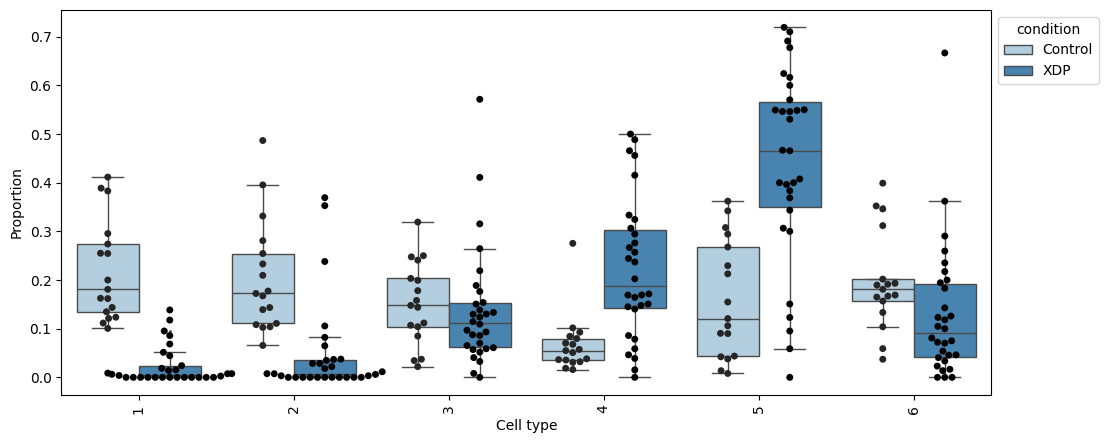

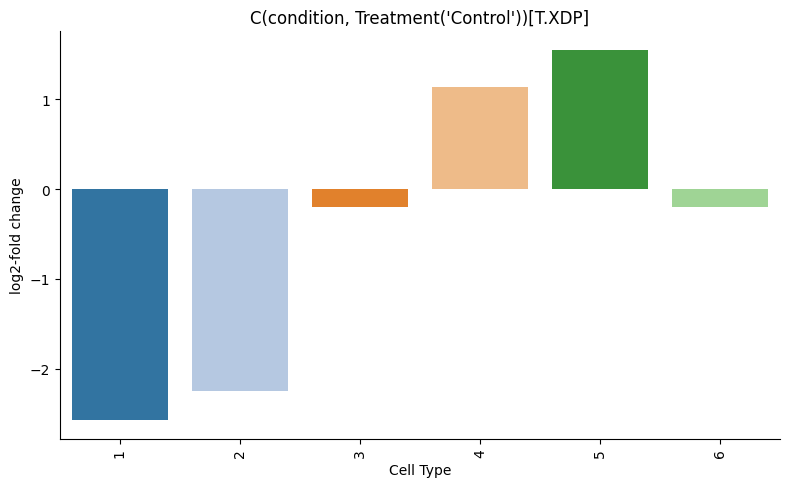

In [ ]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import pertpy as pt
import matplotlib.pyplot as plt
%matplotlib inline

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_VARIABLE    = "donor_id"
CONTRAST_VARIABLE  = "condition"
CONTRAST_BASELINE  = "Control"
CONTRAST_STIM      = "XDP"
REFERENCE_ZONE     = "automatic"          
NUTS_ITERATIONS    = 3000
SAVE_FOLDER        = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/D1_Matrix_zones"
os.makedirs(SAVE_FOLDER, exist_ok=True)

COV_TO_BRING = [CONTRAST_VARIABLE, "sex", SAMPLE_VARIABLE]
FORMULA      = f"C({CONTRAST_VARIABLE}, Treatment('{CONTRAST_BASELINE}')) + sex"

# ── 1. Subset cells ───────────────────────────────────────────────────────────
mask = (
    adata.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"]) & # only D1
    (adata.obs["ct_for_deg"] == "Matrix") # only QC cells
)
adata_sub = adata[mask].to_memory().copy()
print(adata_sub)
print(adata_sub.obs["zone"].value_counts())

# ── 2. Drop samples with missing covariates ───────────────────────────────────
bad_samples = [
    s for cov in COV_TO_BRING
    for s in adata_sub.obs[adata_sub.obs[cov].isna()][SAMPLE_VARIABLE].unique()
]
adata_sub = adata_sub[~adata_sub.obs[SAMPLE_VARIABLE].isin(bad_samples)].copy()

# ── 3. Run scCODA ─────────────────────────────────────────────────────────────
sccoda = pt.tl.Sccoda()

mdata = sccoda.load(
    adata_sub,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="zone",       # ← zones are the "cell types" here
    sample_identifier=SAMPLE_VARIABLE,
    covariate_obs=COV_TO_BRING,
    modality_key_1="coda"
)
print(mdata)

proportions_plot = sccoda.plot_boxplots(
    mdata, feature_name=CONTRAST_VARIABLE, add_dots=True, figsize=(12, 5), return_fig=True
)

mdata = sccoda.prepare(
    mdata,
    formula=FORMULA,
    reference_cell_type=REFERENCE_ZONE,
    automatic_reference_absence_threshold=0.1,
)
print(f"Reference zone: {mdata['coda'].uns['scCODA_params']['reference_cell_type']}")

sccoda.run_nuts(mdata, num_warmup=500, num_samples=NUTS_ITERATIONS, rng_key=42)

# ── 4. Extract results ────────────────────────────────────────────────────────
results = (
    pd.DataFrame(sccoda.credible_effects(mdata, est_fdr=0.05))
    .rename(columns={"Final Parameter": "is_significant"})
    .reset_index()
)
results["Covariate"] = results["Covariate"].str.extract(r'\[T\.(.*?)\]')[0]

effect_df = sccoda.get_effect_df(mdata).reset_index()
effect_df["Covariate"] = effect_df["Covariate"].str.extract(r'T\.(.*)$')[0]

merged_df = effect_df.merge(results, how="left", validate="one_to_one")
display(merged_df[merged_df["Covariate"] == CONTRAST_STIM])

# ── 5. Plot & save ────────────────────────────────────────────────────────────
contrast_nonzero = merged_df[
    (merged_df["Covariate"] == CONTRAST_STIM) &
    (merged_df["log2-fold change"] != 0)
]

if not contrast_nonzero.empty:
    barplot = sccoda.plot_effects_barplot(
        mdata,
        covariates=[CONTRAST_VARIABLE],
        figsize=(12,5),
        parameter="log2-fold change",
        return_fig=True,
    )
    barplot.savefig(f"{SAVE_FOLDER}/logFC_plot.png", bbox_inches="tight", dpi=300)
else:
    print("All effects shrunk to zero — no barplot generated.")

proportions_plot.savefig(f"{SAVE_FOLDER}/proportions.png", bbox_inches="tight", dpi=300)
merged_df.to_csv(f"{SAVE_FOLDER}/results.csv", index=False)

---
---
---